## Trabalho computacional 2. João Victor Silva Santos - 211045632

In [12]:
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
from torch import nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

In [13]:
# Definição do dataset conforme as instruções
class MNIST(d2l.DataModule):
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize), transforms.ToTensor()])
        self.train = torchvision.datasets.MNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.MNIST(
            root=self.root, train=False, transform=trans, download=True)

In [14]:
@d2l.add_to_class(MNIST)
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)

In [15]:
dataset = MNIST(batch_size=64)

In [16]:
class FlexibleMLP(d2l.Classifier):
    def __init__(self, num_outputs=10, hidden_layers=[128], activation=nn.Sigmoid, lr=0.1, optimizer_class=torch.optim.SGD):
        super().__init__()
        self.save_hyperparameters()
        
        #Flatten na primeira camada
        layers = [nn.Flatten()]
        
        # Construção dinâmica das camadas ocultas
        for num_hiddens in hidden_layers:
            layers.append(nn.LazyLinear(num_hiddens))
            layers.append(activation())
            
        # Camada de saída
        layers.append(nn.LazyLinear(num_outputs))
        self.net = nn.Sequential(*layers)

    def configure_optimizers(self):
        # Redefinição para permitir trocar entre SGD e Adam facilmente
        return self.optimizer_class(self.parameters(), lr=self.lr)

# Função auxiliar para treinar e avaliar
def train_and_evaluate(model, dataset, max_epochs=10):
    trainer = d2l.Trainer(max_epochs=max_epochs)
    trainer.fit(model, dataset)

In [17]:
def visualize_misclassifications(model, data_module, num_errors=6):
    model.eval()
    wrong_X, wrong_y, wrong_preds = [], [], []
    
    with torch.no_grad():
        for X, y in data_module.val_dataloader():
            preds = torch.argmax(model(X), axis=1)
            wrong_mask = preds != y
            
            if wrong_mask.any():
                wrong_X.append(X[wrong_mask])
                wrong_y.append(y[wrong_mask])
                wrong_preds.append(preds[wrong_mask])
                
                if sum(len(x) for x in wrong_X) >= num_errors:
                    break

    # Agrupa e corta exatamente na quantidade solicitada
    wrong_X = torch.cat(wrong_X)[:num_errors]
    wrong_y = torch.cat(wrong_y)[:num_errors]
    wrong_preds = torch.cat(wrong_preds)[:num_errors]

    # Prepara as legendas
    labels = [f'Real: {int(y)}\nPred: {int(p)}' for y, p in zip(wrong_y, wrong_preds)]
    
    # Visualiza
    d2l.show_images(wrong_X.squeeze(), 1, num_errors, titles=labels)
    plt.show()

In [18]:
def plot_confusion_matrix(model, data_module):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X, y in data_module.val_dataloader():
            preds = torch.argmax(model(X), axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    
    # Exibição visual da Matriz
    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)
    
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center', 
                color='white' if val > cm.max()/2 else 'black')
                
    plt.xlabel('Predição')
    plt.ylabel('Classe Real')
    plt.title('Matriz de Confusão MNIST')
    plt.show()

In [19]:
def evaluate_accuracy(model, data_iter):
    model.eval()
    metric = d2l.Accumulator(2)
    with torch.no_grad():       
        for X, y in data_iter:
            metric.add(d2l.accuracy(model(X), y), y.numel())
    model.train()
    return metric[0] / metric[1]

In [20]:
# Função para fixar a semente e garantir reprodutibilidade dos testes
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

In [21]:
# Loop automatizado para treinamento com multiplas seeds
def run_multiple_rounds(model_class, kwargs, dataset, num_rounds=3, max_epochs=10):
    accuracies = []
    
    for i in range(num_rounds):
        # Muda a semente a cada rodada
        set_seed(42 + i) 
        print(f"\n--- Iniciando Rodada {i+1}/{num_rounds} ---")
        
        # Instancia um modelo novo
        model = model_class(**kwargs)
        trainer = d2l.Trainer(max_epochs=max_epochs)
        
        # Treinamento
        trainer.fit(model, dataset)
        
        # Avaliação
        acc = evaluate_accuracy(model, dataset.val_dataloader())
        accuracies.append(acc)
        #print(f"Acurácia final da Rodada {i+1}: {acc:.4f}")
        
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    for i, acc in enumerate(accuracies):
        print(f"Acurácia final da Rodada {i+1}: {acc:.4f}")
    
    print(f"\n=== Resultado Final ({num_rounds} rodadas) ===")
    print(f"Acurácia Média: {mean_acc:.4f} ± {std_acc:.4f}")
    
    return mean_acc, std_acc

### Perceptron de uma camada escondida

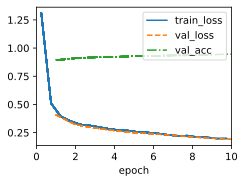

In [22]:
model_2a = FlexibleMLP(hidden_layers=[128], activation=nn.Sigmoid, lr=0.1, optimizer_class=torch.optim.SGD)
train_and_evaluate(model_2a, dataset)

In [23]:
evaluate_accuracy(model_2a, dataset.val_dataloader())

0.946

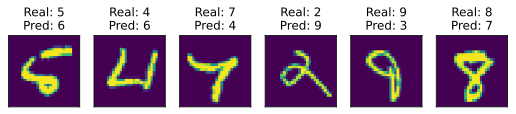

In [24]:
visualize_misclassifications(model_2a, dataset)

> É razoável que um humano cometesse esses erros, principalmente quando o sete não tem o traço ou quando a perna do dois é muito grande.

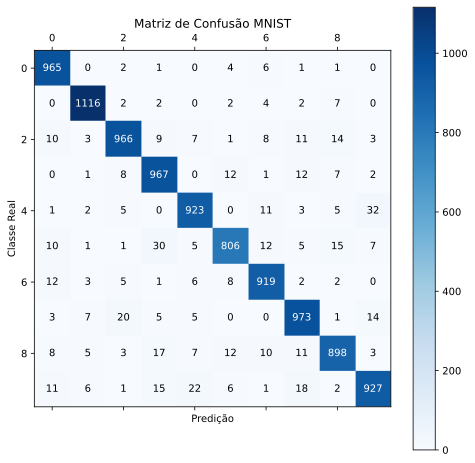

In [25]:
plot_confusion_matrix(model_2a, dataset)

Acurácia final da Rodada 1: 0.9423
Acurácia final da Rodada 2: 0.9454
Acurácia final da Rodada 3: 0.9427

=== Resultado Final (3 rodadas) ===
Acurácia Média: 0.9435 ± 0.0014


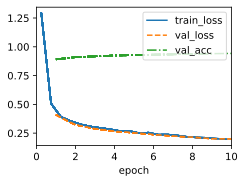

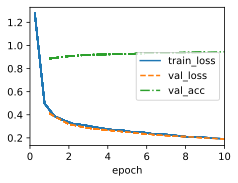

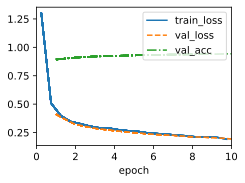

In [26]:
print("Análise Item 2a: Sigmoide + SGD")
kwargs_2a = {
    'hidden_layers': [128], 
    'activation': nn.Sigmoid, 
    'lr': 0.1, 
    'optimizer_class': torch.optim.SGD
}
media_2a, std_2a = run_multiple_rounds(FlexibleMLP, kwargs_2a, dataset, num_rounds=3)

### Otimizador Adam

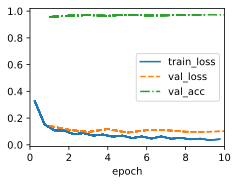

In [27]:
model_2b = FlexibleMLP(hidden_layers=[128], activation=nn.Sigmoid, lr=0.01, optimizer_class=torch.optim.Adam)
train_and_evaluate(model_2b, dataset)

In [28]:
evaluate_accuracy(model_2b, dataset.val_dataloader())

0.9715

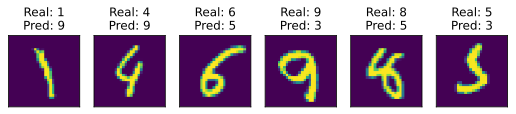

In [29]:
visualize_misclassifications(model_2b, dataset)

> Nas confusões entre 4 e 9, e 5 e 3 é razoável que um ser humano errasse, porém nas outros não.

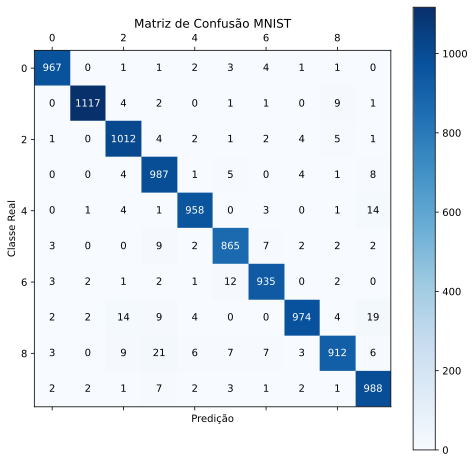

In [30]:
plot_confusion_matrix(model_2b, dataset)

Acurácia final da Rodada 1: 0.9745
Acurácia final da Rodada 2: 0.9750
Acurácia final da Rodada 3: 0.9751

=== Resultado Final (3 rodadas) ===
Acurácia Média: 0.9749 ± 0.0003


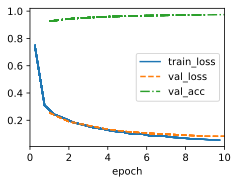

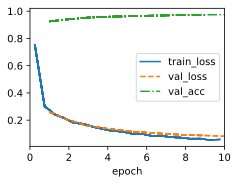

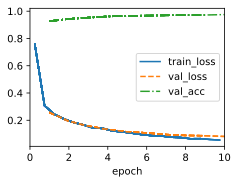

In [31]:
print("Análise Item 2b: Sigmoide + Adam")
kwargs_2b = {
    'hidden_layers': [128], 
    'activation': nn.Sigmoid, 
    'lr': 0.001,  # Adam requer LR menor
    'optimizer_class': torch.optim.Adam
}
media_2b, std_2b = run_multiple_rounds(FlexibleMLP, kwargs_2b, dataset, num_rounds=3)

### Função Relu

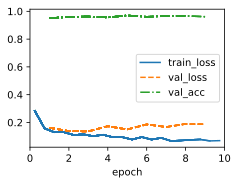

In [ ]:
model_2c = FlexibleMLP(hidden_layers=[128], activation=nn.ReLU, lr=0.01, optimizer_class=torch.optim.Adam)
train_and_evaluate(model_2c, dataset)

In [ ]:
evaluate_accuracy(model_2c, dataset.val_dataloader())

In [ ]:
visualize_misclassifications(model_2c, dataset)

> É razoável que um humano cometesse esses erros, principalmente quando o sete não tem o traço ou quando o quatro é muito fechado. Mas existem exemplos que eu acredito que o humano sequer entenderia o que está escrito.

In [ ]:
plot_confusion_matrix(model_2c, dataset)

In [ ]:
print("Análise Item 2c: ReLU + Adam")
kwargs_2c = {
    'hidden_layers': [128], 
    'activation': nn.ReLU, 
    'lr': 0.001, 
    'optimizer_class': torch.optim.Adam
}
media_2c, std_2c = run_multiple_rounds(FlexibleMLP, kwargs_2c, dataset, num_rounds=3)

### Redes maiores: camada maior

In [ ]:
# Uma camada com 256
model_2d_1 = FlexibleMLP(hidden_layers=[256], activation=nn.ReLU, lr=0.01, optimizer_class=torch.optim.Adam)
train_and_evaluate(model_2d_1, dataset)

In [ ]:
evaluate_accuracy(model_2d_1, dataset.val_dataloader())

In [ ]:
visualize_misclassifications(model_2d_1, dataset)

> Com exceção da confusão entre 2 e 9, as demais não seriam rasoáveis de um humano cometer.

In [ ]:
plot_confusion_matrix(model_2d_1, dataset)

In [ ]:
print("Análise Item 2d: ReLU + Adam (1 Camada Maior)")
kwargs_2d = {
    'hidden_layers': [256], 
    'activation': nn.ReLU, 
    'lr': 0.001, 
    'optimizer_class': torch.optim.Adam
}
media_2d, std_2d = run_multiple_rounds(FlexibleMLP, kwargs_2d, dataset, num_rounds=3)

### Redes maiores: duas camadas

In [ ]:
# Duas camadas (ex: 256 e 128)
model_2d_2 = FlexibleMLP(hidden_layers=[256, 128], activation=nn.ReLU, lr=0.01, optimizer_class=torch.optim.Adam)
train_and_evaluate(model_2d_2, dataset)

In [ ]:
evaluate_accuracy(model_2d_2, dataset.val_dataloader())

In [ ]:
visualize_misclassifications(model_2d_2, dataset)

> Assim como nos demais modelos, os erros causados por 7 sem traço e 4 muitos fechados são razoáveis.

In [ ]:
plot_confusion_matrix(model_2d_2, dataset)

In [ ]:
print("Análise Item 2d: ReLU + Adam (2 Camadas Ocultas)")
kwargs_2d = {
    'hidden_layers': [256, 128], 
    'activation': nn.ReLU, 
    'lr': 0.001, 
    'optimizer_class': torch.optim.Adam
}
media_2d, std_2d = run_multiple_rounds(FlexibleMLP, kwargs_2d, dataset, num_rounds=3)

### 3 e 4

A visualização dos padrões classificados de maneira equivocada nos permitiu ter uma primeira intuição dos principais erros cometidos pelos modelos, que posteriormente foram reforçados e complementados pelas matrizes de confusão.

Foi possível observar que as principais confusões cometidas de forma geral pelos modelos foram:

7 com 2, 3 com 5, 5 com 6, 4 com 9, 8 com 3

Essas confusões são razoáveis quando o sete não possui traço, o três é muito fechado ou tem parte superior parecida com a do 5, quando a parte superior do 5 é muito arredondada, quando o quatro é muito fechado.

Observou-se no treinamento de múltiplos modelos que a aleatoriedade dos pesos afeta o desempenho final dos modelos, mas tem baixo desvio padrão, pelo menos nos casos deste trabalho.

Também é possível notar que a mudança do método de SGD para Adam melhorou o desempenho dos modelos de forma considerável. Já a mudança do tipo da camada de ativação não representou melhoria notável.

O aumento do número de neurônios no modelo de uma única camada escondida apresentou melhorias comparado ao modelo original com otimizador adam. Porém aumentar a complexidade do modelo para duas camadas escondidas não representou melhorias.

